In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('/Users/earltavera/Desktop/MSE803/Week 3/Week2A2/messy_dataset.csv')

# Initial exploration to identify "messy" elements
info = df.info()
head = df.head()
missing_values = df.isnull().sum()

print("--- Initial Head ---")
print(head)
print("\n--- Missing Values ---")
print(missing_values)

# Data Cleaning
# 1. Handling missing values (using median for numeric, mode for categorical/placeholders)
df_cleaned = df.copy()
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# 2. Removing duplicates
duplicates_count = df_cleaned.duplicated().sum()
df_cleaned = df_cleaned.drop_duplicates()

# Correlation Heatmap (Pearson)
plt.figure(figsize=(10, 8))
correlation_matrix = df_cleaned.select_dtypes(include=[np.number]).corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.close()

# Outlier Detection using IQR
outliers_summary = {}
for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

print("\n--- Outlier Count (IQR Method) ---")
print(outliers_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         9 non-null      float64
 1   Name       9 non-null      object 
 2   Age        8 non-null      object 
 3   Country    9 non-null      object 
 4   Salary     8 non-null      object 
 5   Join Date  9 non-null      object 
dtypes: float64(1), object(5)
memory usage: 612.0+ bytes
--- Initial Head ---
    ID     Name           Age Country Salary   Join Date
0  1.0    Alice            25      NZ  55000  15/01/2020
1  2.0      Bob           NaN      NZ  60000  20/02/2020
2  2.0      Bob            30      NZ    NaN  20/02/2020
3  4.0  Charlie            35     AUS  72000         NaN
4  5.0    David  thirty-eight      NZ  68000   1/11/2019

--- Missing Values ---
ID           1
Name         1
Age          2
Country      1
Salary       2
Join Date    1
dtype: int64

--- Outlier Count (IQR Method) 

Outlier counts per column: {'ID': np.int64(0), 'Age': np.int64(0), 'Salary': np.int64(1)}
             ID        Age       Salary
count  10.00000  10.000000     10.00000
mean    5.90000  30.500000  61600.00000
std     3.60401   5.637178   5037.63613
min     1.00000  22.000000  55000.00000
25%     2.50000  27.500000  59250.00000
50%     6.00000  29.500000  60000.00000
75%     8.75000  33.750000  63000.00000
max    11.00000  40.000000  72000.00000


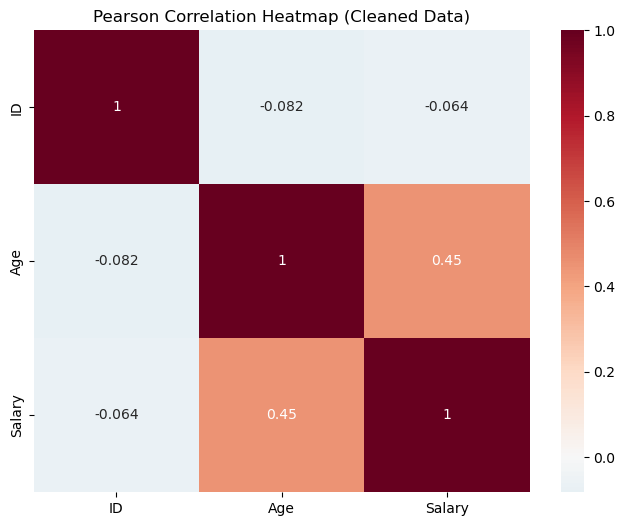

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reload to ensure fresh start
df = pd.read_csv('/Users/earltavera/Desktop/MSE803/Week 3/Week2A2/messy_dataset.csv')

# --- DATA CLEANING ---
# 1. Age: Convert 'thirty-eight' to 38, handle non-numerics, then fill NaNs
df['Age'] = df['Age'].replace('thirty-eight', 38)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Salary: Remove any potential characters and convert to numeric
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# 3. ID: Fill missing ID and ensure numeric
df['ID'] = pd.to_numeric(df['ID'], errors='coerce')
df['ID'] = df['ID'].fillna(df['ID'].max() + 1)

# 4. Remove Duplicates
df = df.drop_duplicates(subset=['Name', 'Age', 'Country', 'Salary'], keep='first')

# Select only numeric columns for correlation and outlier detection
numeric_df = df[['ID', 'Age', 'Salary']]

# --- VISUALIZATION: PEARSON CORRELATION ---
plt.figure(figsize=(8, 6))
correlation_matrix = numeric_df.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Pearson Correlation Heatmap (Cleaned Data)')
plt.savefig('cleaned_correlation_heatmap.png')

# --- OUTLIER DETECTION ---
# Re-calculating with cleaned numeric data
outliers_report = {}
for col in numeric_df.columns:
    q1 = numeric_df[col].quantile(0.25)
    q3 = numeric_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
    outliers_report[col] = count

print("Outlier counts per column:", outliers_report)
print(numeric_df.describe())

--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         9 non-null      float64
 1   Name       9 non-null      object 
 2   Age        8 non-null      object 
 3   Country    9 non-null      object 
 4   Salary     8 non-null      object 
 5   Join Date  9 non-null      object 
dtypes: float64(1), object(5)
memory usage: 612.0+ bytes

--- Initial Head ---
    ID     Name           Age Country Salary   Join Date
0  1.0    Alice            25      NZ  55000  15/01/2020
1  2.0      Bob           NaN      NZ  60000  20/02/2020
2  2.0      Bob            30      NZ    NaN  20/02/2020
3  4.0  Charlie            35     AUS  72000         NaN
4  5.0    David  thirty-eight      NZ  68000   1/11/2019

--- Missing Values Before Cleaning ---
ID           1
Name         1
Age          2
Country      1
Salary       2
Join Date    1
dtype: 

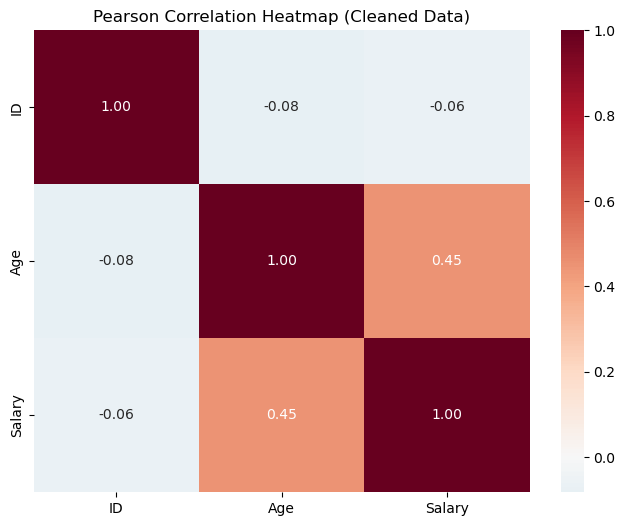


--- Outlier Count (IQR Method) ---
{'ID': np.int64(0), 'Age': np.int64(0), 'Salary': np.int64(1)}

--- Descriptive Statistics (Cleaned Data) ---
             ID        Age       Salary
count  10.00000  10.000000     10.00000
mean    5.90000  30.500000  61600.00000
std     3.60401   5.637178   5037.63613
min     1.00000  22.000000  55000.00000
25%     2.50000  27.500000  59250.00000
50%     6.00000  29.500000  60000.00000
75%     8.75000  33.750000  63000.00000
max    11.00000  40.000000  72000.00000


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
# Note: Path simplified to relative path as per standard environment usage
file_path = 'messy_dataset.csv'
df = pd.read_csv(file_path)

# --- 1. INITIAL EXPLORATION ---
print("--- Initial Info ---")
df.info()
print("\n--- Initial Head ---")
print(df.head())
print("\n--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# --- 2. DATA CLEANING ---
df_cleaned = df.copy()

# A. Handle Age: Convert text 'thirty-eight' to 38, handle non-numerics, fill NaNs with median
df_cleaned['Age'] = df_cleaned['Age'].replace('thirty-eight', 38)
df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce')
df_cleaned['Age'] = df_cleaned['Age'].fillna(df_cleaned['Age'].median())

# B. Handle Salary: Convert to numeric, fill NaNs with median
df_cleaned['Salary'] = pd.to_numeric(df_cleaned['Salary'], errors='coerce')
df_cleaned['Salary'] = df_cleaned['Salary'].fillna(df_cleaned['Salary'].median())

# C. Handle ID: Ensure numeric and fill missing IDs (max + 1)
df_cleaned['ID'] = pd.to_numeric(df_cleaned['ID'], errors='coerce')
df_cleaned['ID'] = df_cleaned['ID'].fillna(df_cleaned['ID'].max() + 1)

# D. Remove Duplicates: Based on core descriptive columns
df_cleaned = df_cleaned.drop_duplicates(subset=['Name', 'Age', 'Country', 'Salary'], keep='first')

# --- 3. CORRELATION ANALYSIS (PEARSON) ---
# Select only numeric columns for correlation
numeric_cols = ['ID', 'Age', 'Salary']
numeric_df = df_cleaned[numeric_cols]

plt.figure(figsize=(8, 6))
correlation_matrix = numeric_df.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Pearson Correlation Heatmap (Cleaned Data)')
plt.savefig('combined_correlation_heatmap.png')
plt.show()

# --- 4. OUTLIER DETECTION (IQR METHOD) ---
outliers_report = {}
for col in numeric_cols:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    count = ((numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)).sum()
    outliers_report[col] = count

print("\n--- Outlier Count (IQR Method) ---")
print(outliers_report)

print("\n--- Descriptive Statistics (Cleaned Data) ---")
print(numeric_df.describe())